# Topic 4: Linear Regression


In [18]:
# please format the following table to read in python using numpy
import numpy as np
data = np.array([
0,22.8,
2.3,22.8,
4.9,22.8,
9.1,20.6,
13.7,13.9,
18.3,11.7,
22.9,11.1,
27.2,11.1]).T


In [19]:
z=data[0::2]
T=data[1::2]
z, T

(array([ 0. ,  2.3,  4.9,  9.1, 13.7, 18.3, 22.9, 27.2]),
 array([22.8, 22.8, 22.8, 20.6, 13.9, 11.7, 11.1, 11.1]))

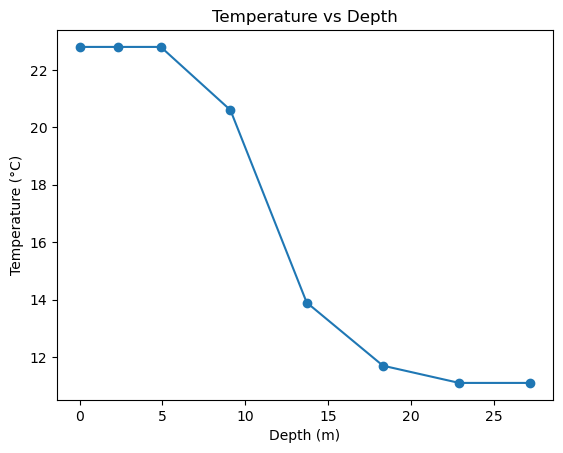

In [20]:

import matplotlib.pyplot as plt
plt.plot(z, T, 'o-')
plt.xlabel('Depth (m)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature vs Depth')
plt.show()

In [21]:
# interpolate the data to find temperature at z = 15 m
from scipy.interpolate import interp1d      
interp_func = interp1d(z, T, kind='linear')
T_15 = interp_func(15)      

In [22]:
# what is in the interp_func object?
print(interp_func)

# show me the coefficients of the linear interpolation
print(interp_func.x)
print(interp_func.y)


[ 0.   2.3  4.9  9.1 13.7 18.3 22.9 27.2]
[22.8 22.8 22.8 20.6 13.9 11.7 11.1 11.1]


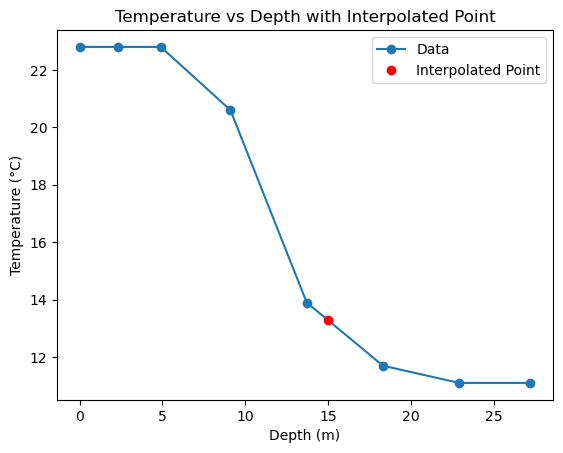

In [23]:
# plot the curve again with the interpolated point
plt.plot(z, T, 'o-', label='Data')
plt.plot(15, T_15, 'ro', label='Interpolated Point')
plt.xlabel('Depth (m)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature vs Depth with Interpolated Point')
plt.legend()
plt.show()

In [24]:
# compute piecewise-linear gradient dT/dz and identify where its magnitude peaks
dz = np.diff(z)
dT = np.diff(T)
grad = dT / dz  # degC per m for each segment
mid_z = z[:-1] + dz / 2  # depth midpoints for each gradient value

max_drop_idx = np.argmin(grad)  # most negative slope = steepest cooling with depth
print(f"Segment mid-depth with steepest cooling: {mid_z[max_drop_idx]:.2f} m")
print(f"dT/dz there: {grad[max_drop_idx]:.2f} degC/m")
print("All segment gradients (degC/m):", grad)


Segment mid-depth with steepest cooling: 11.40 m
dT/dz there: -1.46 degC/m
All segment gradients (degC/m): [ 0.          0.         -0.52380952 -1.45652174 -0.47826087 -0.13043478
  0.        ]


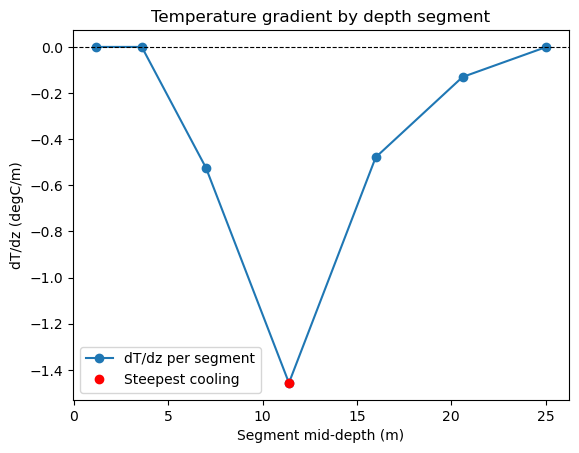

In [25]:
# visualize the gradients by segment midpoint
plt.plot(mid_z, grad, 'o-', label='dT/dz per segment')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.plot(mid_z[max_drop_idx], grad[max_drop_idx], 'ro', label='Steepest cooling')
plt.xlabel('Segment mid-depth (m)')
plt.ylabel('dT/dz (degC/m)')
plt.title('Temperature gradient by depth segment')
plt.legend()
plt.show()


In [26]:
# fit a 3rd-degree polynomial T(z) to the data
coeffs = np.polyfit(z, T, deg=3)
cubic = np.poly1d(coeffs)
z_fit = np.linspace(z.min(), z.max(), 200)
T_fit = cubic(z_fit)

print("Cubic coefficients (highest power first):")
for i, c in enumerate(coeffs):
    power = 3 - i
    print(f"  a{power} = {c:.6f}")
print("\nModel: T(z) = a3*z^3 + a2*z^2 + a1*z + a0")


Cubic coefficients (highest power first):
  a3 = 0.002673
  a2 = -0.100031
  a1 = 0.327707
  a0 = 22.876441

Model: T(z) = a3*z^3 + a2*z^2 + a1*z + a0


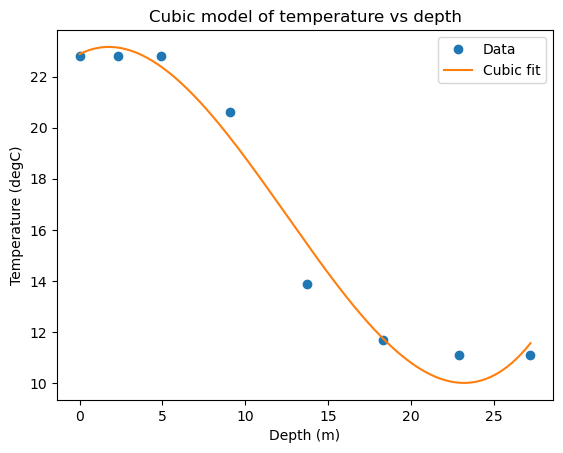

In [27]:
# plot the cubic model alongside the data
plt.plot(z, T, 'o', label='Data')
plt.plot(z_fit, T_fit, '-', label='Cubic fit')
plt.xlabel('Depth (m)')
plt.ylabel('Temperature (degC)')
plt.title('Cubic model of temperature vs depth')
plt.legend()
plt.show()


In [28]:
# build the normal-equation system shown in the figure for the cubic fit
n = len(z)
S = {
    0: n,
    1: np.sum(z),
    2: np.sum(z**2),
    3: np.sum(z**3),
    4: np.sum(z**4),
    5: np.sum(z**5),
    6: np.sum(z**6),
}
b = np.array([
    np.sum(T),
    np.sum(z * T),
    np.sum(z**2 * T),
    np.sum(z**3 * T),
])

A = np.array([
    [S[0], S[1], S[2], S[3]],
    [S[1], S[2], S[3], S[4]],
    [S[2], S[3], S[4], S[5]],
    [S[3], S[4], S[5], S[6]],
])

a = np.linalg.solve(A, b)
print("Normal-equation matrix A:\n", A)
print("Right-hand side b:\n", b)
print("Solution coefficients (a0..a3):", a)
print("polyfit coefficients (a3..a0) for comparison:", coeffs)


Normal-equation matrix A:
 [[8.00000000e+00 9.84000000e+01 1.89894000e+03 4.17158640e+04]
 [9.84000000e+01 1.89894000e+03 4.17158640e+04 9.77209882e+05]
 [1.89894000e+03 4.17158640e+04 9.77209882e+05 2.37861922e+07]
 [4.17158640e+04 9.77209882e+05 2.37861922e+07 5.93929093e+08]]
Right-hand side b:
 [1.36800000e+02 1.31227000e+03 2.29342050e+04 4.82600743e+05]
Solution coefficients (a0..a3): [ 2.28764414e+01  3.27707132e-01 -1.00031046e-01  2.67272524e-03]
polyfit coefficients (a3..a0) for comparison: [ 2.67272524e-03 -1.00031046e-01  3.27707132e-01  2.28764414e+01]


In [29]:
# estimate inflection depth(s) from the cubic: solve d2T/dz2 = 0
p = cubic  # np.poly1d from polyfit
p2 = p.deriv(m=2)
roots = p2.r
real_roots = roots[np.isreal(roots)].real
in_range = real_roots[(real_roots >= z.min()) & (real_roots <= z.max())]

print("Second derivative roots (all real parts):", real_roots)
print("In-depth-range inflection candidates:", in_range)
for r in in_range:
    print(f"  z = {r:.3f} m, T = {p(r):.3f} degC, dT/dz = {p.deriv()(r):.3f} degC/m")

if len(in_range) == 0:
    print("No real inflection within the data depth range")


Second derivative roots (all real parts): [12.47553682]
In-depth-range inflection candidates: [12.47553682]
  z = 12.476 m, T = 16.586 degC, dT/dz = -0.920 degC/m


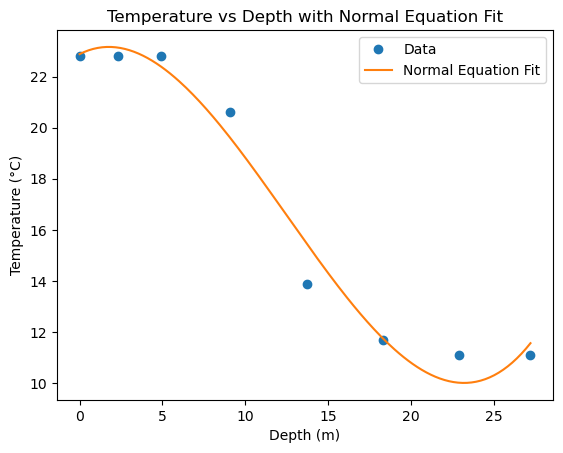

Text(0.5, 0, 'Depth (m)')

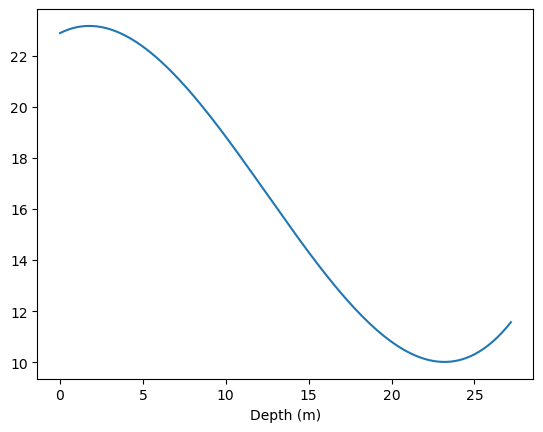

In [30]:
# make the plot with the normal-equation solution and the original points
T_ne = a[3]*z_fit**3 + a[2]*z_fit**2 + a[1]*z_fit + a[0]
plt.plot(z, T, 'o', label='Data')
plt.plot(z_fit, T_ne, '-', label='Normal Equation Fit')
plt.xlabel('Depth (m)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature vs Depth with Normal Equation Fit')
plt.legend()
plt.show()
plt.plot(z_fit, T_ne, '-', label='Normal Equation Fit')
plt.xlabel('Depth (m)')

In [31]:
# for the previous plot, calculate the coefficient of determination R^2 to assess the fit quality
# predicted values from the normal equation fit at the original z points
T_pred = a[3]*z**3 + a[2]*z**2 + a[1]*z + a[0]
T_mean = np.mean(T)
SS_tot = np.sum((T - T_mean)**2)  # total sum of squares
SS_res = np.sum((T - T_pred)**2)  # residual sum of squares
R_squared = 1 - (SS_res / SS_tot)
print(f"Coefficient of determination R^2: {R_squared:.4f}")


Coefficient of determination R^2: 0.9768


In [32]:
# estimate where d^2T/dz^2 = 0 (inflection point)
# for cubic: T(z)=a3 z^3 + a2 z^2 + a1 z + a0
# d2T/dz2 = 6 a3 z + 2 a2 => z0 = -a2 / (3 a3)
if a[3] != 0:
    z0 = -a[2] / (3 * a[3])
    print(f"Inflection point (max gradient) at z ≈ {z0:.4f} m")
    # optional: gradient at that point
    dTdz = 3*a[3]*z0**2 + 2*a[2]*z0 + a[1]
    print(f"Maximum gradient dT/dz ≈ {dTdz:.4f} °C/m")
else:
    print("Cubic term is zero; no inflection point for a quadratic/linear fit.")


Inflection point (max gradient) at z ≈ 12.4755 m
Maximum gradient dT/dz ≈ -0.9202 °C/m


In [34]:
# R^2 for three segments: first 3, next 2, last 3 points
# predicted values from the normal-equation fit at the original z points
T_pred_all = a[3]*z**3 + a[2]*z**2 + a[1]*z + a[0]

segments = {
    "first 3": slice(0, 4),
    "next 2": slice(3, 5),
    "last 3": slice(4, 8),
}

for label, sl in segments.items():
    T_seg = T[sl]
    T_pred_seg = T_pred_all[sl]
    T_mean = np.mean(T_seg)
    SS_tot = np.sum((T_seg - T_mean)**2)
    SS_res = np.sum((T_seg - T_pred_seg)**2)
    if SS_tot == 0:
        R_squared = float('nan')
    else:
        R_squared = 1 - (SS_res / SS_tot)
    print(f"Segment '{label}': R^2 = {R_squared:.4f}")


Segment 'first 3': R^2 = 0.6410
Segment 'next 2': R^2 = 0.8455
Segment 'last 3': R^2 = 0.2782


## Linear regression and the Chapra & Canale error measures ($S_t$ and $S_r$)

Given data points $(x_i, y_i)$ and a straight-line model

$$
\hat{y}_i = a_0 + a_1 x_i,
$$

Chapra & Canale define:

### Total sum of squares
Measures the total variability in the data around the mean:

$$
S_t = \sum_{i=1}^{n} (y_i - \bar{y})^2
\quad\text{with}\quad
\bar{y} = \frac{1}{n}\sum_{i=1}^{n} y_i.
$$

### Residual (error) sum of squares
Measures the variability not explained by the regression line:

$$
S_r = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2.
$$

### Coefficient of determination
The fraction of variance explained by the model:

$$
r^2 = 1 - \frac{S_r}{S_t}.
$$

- If the points lie close to a line, $S_r \ll S_t$ and $r^2 \approx 1$.
- If the data are very scattered, $S_r$ is larger and $r^2$ decreases.

In this notebook we generate two datasets with the same underlying line:
1) **Low dispersion** (small noise)
2) **High dispersion** (large noise)

and compute $S_t$, $S_r$, and $r^2$ for each case.



=== Low dispersion dataset ===
Fitted line: y = a0 + a1 x
  a0 = 9.8839
  a1 = 2.5070
St = Σ (y_i - ȳ)^2  = 899.830153
Sr = Σ (y_i - ŷ_i)^2 = 1.989177
r^2 = 1 - Sr/St      = 0.997789
s_y/x = sqrt(Sr/(n-2)) = 0.391170

=== High dispersion dataset ===
Fitted line: y = a0 + a1 x
  a0 = 7.2735
  a1 = 2.6297
St = Σ (y_i - ȳ)^2  = 1097.117584
Sr = Σ (y_i - ŷ_i)^2 = 109.245195
r^2 = 1 - Sr/St      = 0.900425
s_y/x = sqrt(Sr/(n-2)) = 2.898875


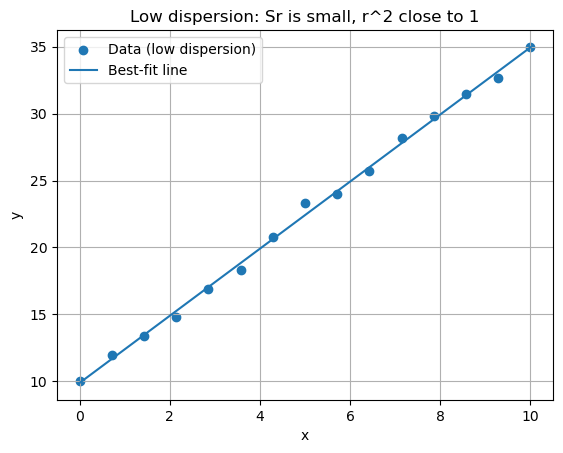

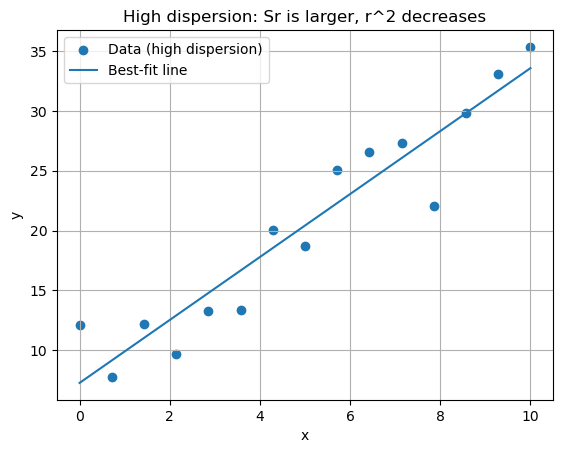

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def fit_line_and_stats(x, y):
    """
    Fit y ≈ a0 + a1 x using least squares and compute Chapra & Canale statistics:
    St (total sum of squares), Sr (residual sum of squares), r^2.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)

    # Design matrix for y = a0 + a1*x
    A = np.column_stack([np.ones(n), x])

    # Least squares solution (a0, a1)
    coeffs, residuals, rank, s = np.linalg.lstsq(A, y, rcond=None)
    a0, a1 = coeffs

    # Predictions
    yhat = a0 + a1 * x

    # Chapra & Canale sums
    ybar = np.mean(y)
    St = np.sum((y - ybar) ** 2)
    Sr = np.sum((y - yhat) ** 2)

    # Coefficient of determination
    r2 = 1.0 - (Sr / St) if St > 0 else np.nan

    # Optional: standard error of estimate (often shown alongside Sr)
    # s_y/x = sqrt(Sr / (n-2)) for straight-line regression
    syx = np.sqrt(Sr / (n - 2)) if n > 2 else np.nan

    return a0, a1, St, Sr, r2, syx, yhat


# --------------------------
# Create two datasets
# --------------------------
rng = np.random.default_rng(7)

# "True" underlying line
a0_true = 10.0
a1_true = 2.5

# x values (same for both cases)
x = np.linspace(0, 10, 15)

# Low dispersion (small noise)
sigma_low = 0.6
y_low = a0_true + a1_true * x + rng.normal(0, sigma_low, size=len(x))

# High dispersion (larger noise)
sigma_high = 3.0
y_high = a0_true + a1_true * x + rng.normal(0, sigma_high, size=len(x))


# --------------------------
# Fit and compute St, Sr, r^2
# --------------------------
a0L, a1L, StL, SrL, r2L, syxL, yhatL = fit_line_and_stats(x, y_low)
a0H, a1H, StH, SrH, r2H, syxH, yhatH = fit_line_and_stats(x, y_high)

# Print results neatly
def print_report(label, a0, a1, St, Sr, r2, syx):
    print(f"\n=== {label} ===")
    print(f"Fitted line: y = a0 + a1 x")
    print(f"  a0 = {a0:.4f}")
    print(f"  a1 = {a1:.4f}")
    print(f"St = Σ (y_i - ȳ)^2  = {St:.6f}")
    print(f"Sr = Σ (y_i - ŷ_i)^2 = {Sr:.6f}")
    print(f"r^2 = 1 - Sr/St      = {r2:.6f}")
    print(f"s_y/x = sqrt(Sr/(n-2)) = {syx:.6f}")

print_report("Low dispersion dataset", a0L, a1L, StL, SrL, r2L, syxL)
print_report("High dispersion dataset", a0H, a1H, StH, SrH, r2H, syxH)


# --------------------------
# Plot: two panels
# --------------------------
fig1 = plt.figure()
plt.scatter(x, y_low, label="Data (low dispersion)")
plt.plot(x, yhatL, label="Best-fit line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Low dispersion: Sr is small, r^2 close to 1")
plt.legend()
plt.grid(True)
plt.show()

fig2 = plt.figure()
plt.scatter(x, y_high, label="Data (high dispersion)")
plt.plot(x, yhatH, label="Best-fit line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("High dispersion: Sr is larger, r^2 decreases")
plt.legend()
plt.grid(True)
plt.show()
